# Transport in sector-specific hydrogen markets

Compare transport activity and impacts from 2030 to 2050 for **1 kg of hydrogen, gaseous, low pressure** supplied by one sector market. Edit the settings below, then run all cells. All tables and plots stay inline; there are no exports.

This notebook reuses `LCIA_mapping_h2.py` and the calculation/stage helpers in `run_analysis.py`. Production is calculated for reconciliation, but excluded from the plotted distribution results. Transport includes the upstream burdens of the mapped transport services. The existing stage helper separates mapped pipeline compression and direct H₂/NH₃ leakage; other embedded service inputs remain in the service footprint. This is a mapped contribution analysis, not a decomposition of every upstream transport activity in the economy.


In [194]:
from pathlib import Path
import sys
import math
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bw2data as bd
from IPython.display import display

# Same module-resolution pattern as the existing analysis notebooks.
candidates = [Path.cwd(), Path.cwd().parent,
              Path.cwd() / "examples" / "h2-distribution_LCIA"]
ANALYSIS_DIR = next(p.resolve() for p in candidates
                    if (p / "LCIA_mapping_h2.py").exists())
sys.path.insert(0, str(ANALYSIS_DIR))
import config as cfg
import LCIA_mapping_h2 as mapping
from run_analysis import (select_methods, calculate_lcia,
                          analyze_hydrogen_life_cycle_stages)

plt.rcParams.update({"font.size": 10, "axes.titlesize": 11})


## 1. Settings and available databases

Choose an existing project and run the next cell to list its mapped databases for the requested years. Then select database names in the following cell. The general mapping remains unchanged; databases absent from this project are simply excluded.

Steel is the initial sector. Region selection tries EUR first, then WEU. Change these settings for another geographical scope. Missing years remain gaps; a missing 2030 database prevents normalization for that scenario but does not prevent absolute plots.


In [ ]:
PROJECT = "ecoinvent-3.12-cutoff_v2"
SECTOR = "Transport"
REGION = "EUR"
REGION_FALLBACKS = ("WEU",)
BASE_YEAR = 2030
YEARS = [2030, 2040, 2050]

assert SECTOR in cfg.EXPECTED_SECTOR_MARKETS
assert BASE_YEAR in YEARS and len(YEARS) == len(set(YEARS))
if PROJECT not in bd.projects:
    raise LookupError(f"Existing Brightway project required: {PROJECT}")
bd.projects.set_current(PROJECT)
available_records = [dict(item) for item in mapping.DATABASES
                     if item["database"] in bd.databases and item["year"] in YEARS]
if not available_records:
    raise LookupError("No mapped databases for these years are available in this project.")
print(f"Mapped databases available in {PROJECT}:")
display(pd.DataFrame(available_records))
print("Project databases without mapping metadata (not selectable here):")
print(sorted(set(bd.databases) - {item["database"] for item in mapping.DATABASES}))


Mapped databases available in ecoinvent-3.12-cutoff_v2:

,database,iam_model,scenario,year
0,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,remind,SSP1-PkBudg650,2030
1,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,remind,SSP1-PkBudg650,2040
2,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,remind,SSP1-PkBudg650,2050
3,ecoinvent-3.12-cutoff_image-SSP1-VLLO_2030_08_...,image,SSP1-VLLO,2030
4,ecoinvent-3.12-cutoff_image-SSP1-VLLO_2040_08_...,image,SSP1-VLLO,2040
5,ecoinvent-3.12-cutoff_image-SSP1-VLLO_2050_08_...,image,SSP1-VLLO,2050
6,ecoinvent-3.12-cutoff_message-SSP1-VL_2030_08_...,message,SSP1-VL,2030
7,ecoinvent-3.12-cutoff_message-SSP1-VL_2040_08_...,message,SSP1-VL,2040
8,ecoinvent-3.12-cutoff_message-SSP1-VL_2050_08_...,message,SSP1-VL,2050


Project databases without mapping metadata (not selectable here):
['biosphere-3.12']


In [196]:
# None selects all available mapped databases shown above.
# To choose a subset, replace None with a list of exact database names from the table.
SELECTED_DATABASES = [
# Available in ecoinvent-3.12
    #"ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2030_08_full",
    #"ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full",
    #"ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2050_08_full",
    #"ecoinvent-3.12-cutoff_tiam-ucl-RCP19_2030_08_full",
    #"ecoinvent-3.12-cutoff_tiam-ucl-RCP19_2040_08_full",
    #"ecoinvent-3.12-cutoff_tiam-ucl-RCP19_2050_08_full",
    #"ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2030_08_full",
    #"ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2040_08_full",
    #"ecoinvent-3.12-cutoff_remind-SSP2-PkBudg1000_2050_08_full",
    #"ecoinvent-3.12-cutoff_image-SSP2-VLHO_2030_08_full",
    #"ecoinvent-3.12-cutoff_image-SSP2-VLHO_2040_08_full",
    #"ecoinvent-3.12-cutoff_image-SSP2-VLHO_2050_08_full",
    #"ecoinvent-3.12-cutoff_message-SSP2-L_2030_08_full",
    #"ecoinvent-3.12-cutoff_message-SSP2-L_2040_08_full",
    #"ecoinvent-3.12-cutoff_message-SSP2-L_2050_08_full",
# Available in ecoinvent-3.12_v2
    "ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2030_08_full",
    "ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2040_08_full",
    "ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2050_08_full",
    #"ecoinvent-3.12-cutoff_image-SSP1-VLLO_2030_08_full",
    #"ecoinvent-3.12-cutoff_image-SSP1-VLLO_2050_08_full",
    #"ecoinvent-3.12-cutoff_message-SSP1-VL_2030_08_full",
    #"ecoinvent-3.12-cutoff_message-SSP1-VL_2050_08_full",
    #"ecoinvent-3.12-cutoff_image-SSP1-VLLO_2040_08_full",
    #"ecoinvent-3.12-cutoff_message-SSP1-VL_2040_08_full",
]
if bd.projects.current != PROJECT:
    raise RuntimeError("Project changed: rerun the settings cell before selecting databases.")
names = ([item["database"] for item in available_records]
         if SELECTED_DATABASES is None else list(SELECTED_DATABASES))
if not names or len(names) != len(set(names)):
    raise ValueError("Select at least one database, with no duplicate names.")
allowed = {item["database"] for item in available_records}
unknown = set(names) - (allowed & set(bd.databases))
if unknown:
    raise ValueError(f"Select names from the available database table: {sorted(unknown)}")
records = [dict(item, label=mapping.SCENARIO_LABELS[(item["iam_model"], item["scenario"])])
           for item in available_records if item["database"] in names]
keys = [(r["iam_model"], r["scenario"], r["year"]) for r in records]
if len(keys) != len(set(keys)):
    raise ValueError("Select only one database per scenario/year.")
SCENARIOS = list(dict.fromkeys((r["iam_model"], r["scenario"]) for r in records))
scenario_labels = {key: mapping.SCENARIO_LABELS[key] for key in SCENARIOS}
for label in scenario_labels.values():
    selected_years = {r["year"] for r in records if r["label"] == label}
    if BASE_YEAR not in selected_years:
        warnings.warn(f"{label}: no selected {BASE_YEAR} database; absolute plots only.")
display(pd.DataFrame(records))

,database,iam_model,scenario,year,label
0,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,remind,SSP1-PkBudg650,2030,REMIND - SSP1-PkBudg650
1,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,remind,SSP1-PkBudg650,2040,REMIND - SSP1-PkBudg650
2,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,remind,SSP1-PkBudg650,2050,REMIND - SSP1-PkBudg650


## 1b. Available sector markets by region and year

Run this check before the LCIA calculation. It lists all matching sector-market names in the selected databases at the preferred region and its fallbacks. The summary shows the location that would be selected (preferred region first), missing markets, duplicate matches, and years without a selected database. Generic markets are excluded. No LCIA is run.

Use the sector labels in the summary to choose `SECTOR` above. Newly discovered names without a configured sector label are listed by their suffix and need an entry in `cfg.EXPECTED_SECTOR_MARKETS` before the existing analysis selector can use them.


In [197]:
if bd.projects.current != PROJECT:
    raise RuntimeError("Project changed: rerun section 1 before checking sector availability.")

regions = list(dict.fromkeys((REGION, *REGION_FALLBACKS)))
prefix = cfg.GENERIC_MARKET_NAME + ", "
market_labels = {name: label for label, name in cfg.EXPECTED_SECTOR_MARKETS.items()}
market_rows = []
for record in records:
    for activity in bd.Database(record["database"]):
        name = activity.get("name", "")
        location = activity.get("location")
        if (name.startswith(prefix) and location in regions
                and activity.get("reference product") == cfg.REFERENCE_PRODUCT
                and activity.get("unit") == cfg.UNIT):
            market_rows.append({
                "scenario": record["label"], "year": record["year"],
                "database": record["database"], "market name": name,
                "sector": market_labels.get(name, name[len(prefix):]),
                "location": location, "activity key": activity.key,
            })
sector_markets = pd.DataFrame(market_rows, columns=[
    "scenario", "year", "database", "market name", "sector", "location", "activity key"])
print("Matching sector markets (including available fallback locations):")
display(sector_markets.sort_values(["scenario", "year", "sector", "location"]))

# Include known sectors even if absent throughout, plus any additional names found.
all_names = list(dict.fromkeys([*market_labels, *sector_markets["market name"]]))
selected_pairs = {(r["label"], r["year"]) for r in records}
availability_rows = []
for scenario in scenario_labels.values():
    for year in YEARS:
        for name in all_names:
            status = "Not available"
            if (scenario, year) not in selected_pairs:
                status = "No selected database"
            else:
                matches = sector_markets.loc[
                    (sector_markets["scenario"] == scenario)
                    & (sector_markets["year"] == year)
                    & (sector_markets["market name"] == name)]
                for location in regions:
                    count = int(matches["location"].eq(location).sum())
                    if count:
                        status = location if count == 1 else f"Ambiguous: {count} at {location}"
                        break
            availability_rows.append({
                "scenario": scenario, "year": year,
                "sector": market_labels.get(name, name[len(prefix):]),
                "market name": name, "availability": status,
            })
sector_availability = pd.DataFrame(availability_rows)
print("Availability by year (entries show the selected region):")
display(sector_availability.pivot(
    index=["scenario", "sector", "market name"], columns="year", values="availability"
).reindex(columns=YEARS))


Matching sector markets (including available fallback locations):


,scenario,year,database,market name,sector,location,activity key
1,REMIND - SSP1-PkBudg650,2030,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,"market for hydrogen, gaseous, low pressure, fo...",Chemicals,EUR,(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2...
2,REMIND - SSP1-PkBudg650,2030,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,"market for hydrogen, gaseous, low pressure, fo...",Heating,EUR,(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2...
0,REMIND - SSP1-PkBudg650,2030,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,"market for hydrogen, gaseous, low pressure, fo...",Transport,EUR,(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2...
3,REMIND - SSP1-PkBudg650,2040,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,"market for hydrogen, gaseous, low pressure, fo...",Chemicals,EUR,(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2...
5,REMIND - SSP1-PkBudg650,2040,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,"market for hydrogen, gaseous, low pressure, fo...",Steel,EUR,(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2...
4,REMIND - SSP1-PkBudg650,2040,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,"market for hydrogen, gaseous, low pressure, fo...",Transport,EUR,(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2...
7,REMIND - SSP1-PkBudg650,2050,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,"market for hydrogen, gaseous, low pressure, fo...",Chemicals,EUR,(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2...
8,REMIND - SSP1-PkBudg650,2050,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,"market for hydrogen, gaseous, low pressure, fo...",Steel,EUR,(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2...
6,REMIND - SSP1-PkBudg650,2050,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,"market for hydrogen, gaseous, low pressure, fo...",Transport,EUR,(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2...


Availability by year (entries show the selected region):


year                                                                                                2030  \
scenario                sector         market name                                                         
REMIND - SSP1-PkBudg650 Cement         market for hydrogen, gaseous, low pressure, for...  Not available   
                        Chemicals      market for hydrogen, gaseous, low pressure, for...            EUR   
                        Heating        market for hydrogen, gaseous, low pressure, for...            EUR   
                        Other end uses market for hydrogen, gaseous, low pressure, for...  Not available   
                        Steel          market for hydrogen, gaseous, low pressure, for...  Not available   
                        Transport      market for hydrogen, gaseous, low pressure, for...            EUR   

year                                                                                                2040  \
scenario                sector         market name                                                         
REMIND - SSP1-PkBudg650 Cement         market for hydrogen, gaseous, low pressure, for...  Not available   
                        Chemicals      market for hydrogen, gaseous, low pressure, for...            EUR   
                        Heating        market for hydrogen, gaseous, low pressure, for...  Not available   
                        Other end uses market for hydrogen, gaseous, low pressure, for...  Not available   
                        Steel          market for hydrogen, gaseous, low pressure, for...            EUR   
                        Transport      market for hydrogen, gaseous, low pressure, for...            EUR   

year                                                                                                2050  
scenario                sector         market name                                                        
REMIND - SSP1-PkBudg650 Cement         market for hydrogen, gaseous, low pressure, for...  Not available  
                        Chemicals      market for hydrogen, gaseous, low pressure, for...            EUR  
                        Heating        market for hydrogen, gaseous, low pressure, for...  Not available  
                        Other end uses market for hydrogen, gaseous, low pressure, for...  Not available  
                        Steel          market for hydrogen, gaseous, low pressure, for...            EUR  
                        Transport      market for hydrogen, gaseous, low pressure, for...            EUR

## 2. Select markets and calculate contributions

The small selector below follows the exact-name/product/unit selection in the existing runner, but only selects our sector. No generic RER market is required. An absent sector market is reported as unavailable; duplicate matches raise an error. The existing stage helper checks that production plus distribution reconstructs the market total for every method.


In [198]:
def select_sector(database):
    candidates = [a for a in database
                  if a.get("name") == cfg.EXPECTED_SECTOR_MARKETS[SECTOR]
                  and a.get("reference product") == cfg.REFERENCE_PRODUCT
                  and a.get("unit") == cfg.UNIT]
    for location in dict.fromkeys((REGION, *REGION_FALLBACKS)):
        matches = [a for a in candidates if a.get("location") == location]
        if len(matches) > 1:
            raise LookupError(f"Multiple {SECTOR} markets at {location} in {database.name}")
        if matches:
            return matches[0]
    return None

if PROJECT not in bd.projects:
    raise LookupError(f"Existing Brightway project required: {PROJECT}")
bd.projects.set_current(PROJECT)
_, methods, method_units, method_table = select_methods()
display(method_table)
missing = [r["database"] for r in records if r["database"] not in bd.databases]
if missing:
    raise LookupError(f"Mapped databases are unavailable: {missing}")

selection_rows, distribution_frames, activity_frames, checks = [], [], [], []
for record in records:
    print(f'{record["label"]} — {record["year"]}')
    market = select_sector(bd.Database(record["database"]))
    metadata = {"scenario": record["label"], "year": record["year"],
                "database": record["database"],
                "location": market.get("location") if market is not None else None}
    selection_rows.append(dict(metadata, status="available" if market is not None else "unavailable",
                               activity_key=market.key if market is not None else None))
    if market is None:
        continue
    selected = {SECTOR: market}
    scores, _ = calculate_lcia(selected, [SECTOR], methods, method_units)
    for index, method in enumerate(methods):
        stage = analyze_hydrogen_life_cycle_stages(
            selected, [SECTOR], method, scores,
            mapping.impact_category_label(method), method_units[method],
            functional_unit=1.0, reconciliation_rtol=cfg.RECONCILIATION_RTOL,
        )
        distribution_frames.append(stage["distribution processes"].assign(**metadata))
        checks.append(stage["reconciliation"].assign(**metadata))
        # Physical demands are method-independent: collect them once.
        if index == 0:
            audit = stage["classification audit"]
            activity_frames.append(audit.loc[
                (audit["stage"] == "Distribution") & (audit["substage"] == "Transport")
            ].assign(**metadata))

selection = pd.DataFrame(selection_rows)
display(selection)
if not distribution_frames:
    raise ValueError("No selected sector markets are available in the requested regions.")
distribution = pd.concat(distribution_frames, ignore_index=True)
activities = pd.concat(activity_frames, ignore_index=True)
reconciliation = pd.concat(checks, ignore_index=True)
display(reconciliation[["scenario", "year", "impact category",
                        "Layer 1 difference", "Layer 2 difference"]])
for scenario, group in selection.groupby("scenario"):
    if group["location"].dropna().nunique() > 1:
        warnings.warn(f"{scenario}: selected region changes across years; inspect selection.")


,method,impact category,indicator,unit
0,"(EF v3.1, acidification, accumulated exceedanc...",acidification,accumulated exceedance (AE),mol H+-Eq
1,"(IPCC 2021, climate change, GWP 100a, incl. H)","climate change — GWP 100a, incl. H2","GWP 100a, incl. H",kg CO2-Eq
2,"(EF v3.1, ecotoxicity: freshwater, comparative...",ecotoxicity: freshwater,comparative toxic unit for ecosystems (CTUe),CTUe
3,"(EF v3.1, energy resources: non-renewable, abi...",energy resources: non-renewable,abiotic depletion potential (ADP): fossil fuels,"MJ, net calorific value"
4,"(EF v3.1, eutrophication: freshwater, fraction...",eutrophication: freshwater,fraction of nutrients reaching freshwater end ...,kg P-Eq
5,"(EF v3.1, eutrophication: marine, fraction of ...",eutrophication: marine,fraction of nutrients reaching marine end comp...,kg N-Eq
6,"(EF v3.1, human toxicity: carcinogenic, compar...",human toxicity: carcinogenic,comparative toxic unit for human (CTUh),CTUh
7,"(EF v3.1, human toxicity: non-carcinogenic, co...",human toxicity: non-carcinogenic,comparative toxic unit for human (CTUh),CTUh
8,"(EF v3.1, material resources: metals/minerals,...",material resources: metals/minerals,abiotic depletion potential (ADP): elements (u...,kg Sb-Eq
9,"(EF v3.1, particulate matter formation, impact...",particulate matter formation,impact on human health,disease incidence


REMIND - SSP1-PkBudg650 — 2030
REMIND - SSP1-PkBudg650 — 2040
REMIND - SSP1-PkBudg650 — 2050


,scenario,year,database,location,status,activity_key
0,REMIND - SSP1-PkBudg650,2030,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,None,unavailable,None
1,REMIND - SSP1-PkBudg650,2040,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,EUR,available,(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2...
2,REMIND - SSP1-PkBudg650,2050,ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_20...,EUR,available,(ecoinvent-3.12-cutoff_remind-SSP1-PkBudg650_2...


,scenario,year,impact category,Layer 1 difference,Layer 2 difference
0,REMIND - SSP1-PkBudg650,2040,acidification,-7.894955e-10,-1.421868e-09
1,REMIND - SSP1-PkBudg650,2040,"climate change — GWP 100a, incl. H2",-2.527077e-08,-4.947189e-08
2,REMIND - SSP1-PkBudg650,2040,ecotoxicity: freshwater,-1.004188e-06,-1.887763e-06
3,REMIND - SSP1-PkBudg650,2040,energy resources: non-renewable,-1.320307e-06,-2.742039e-06
4,REMIND - SSP1-PkBudg650,2040,eutrophication: freshwater,-3.803115e-11,-7.509320e-11
5,REMIND - SSP1-PkBudg650,2040,eutrophication: marine,-8.732765e-11,-1.544759e-10
6,REMIND - SSP1-PkBudg650,2040,human toxicity: carcinogenic,-8.894950e-17,-1.835355e-16
7,REMIND - SSP1-PkBudg650,2040,human toxicity: non-carcinogenic,-5.655151e-15,-1.171782e-14
8,REMIND - SSP1-PkBudg650,2040,material resources: metals/minerals,-4.485565e-12,-9.286826e-12
9,REMIND - SSP1-PkBudg650,2040,particulate matter formation,-4.135128e-15,-7.692739e-15


## 3. Prepare transport and distribution views

Transport excludes separately identified leakage, conversion and reconversion. Physical quantities are service demands per kg H₂, not hydrogen mode shares: tonne-kilometres combine mass and distance, while a pipeline service may use another unit. Units are never added together.

Normalized values divide **total transport impact** by the same scenario/category's 2030 total. Values below 1 mean lower impacts only for a positive baseline. Zero/negative baselines and missing years stay unavailable. Region changes relative to the baseline are flagged in the table.


In [199]:
transport = distribution.loc[
    (distribution["substage"] == "Transport")
    & (distribution["contribution type"] == "Process excluding leakage")
].copy()
mode_order = list(dict.fromkeys(mapping.TRANSPORT_NAMES.values()))
mode_colors = {mode: mapping.ROUTE_COLORS[mapping.distribution_family(mode)]
               for mode in mode_order}
mode_hatches = {mode: mapping.FAMILY_STYLES[mapping.distribution_family(mode)]["hatch"]
                for mode in mode_order}
labels = list(scenario_labels.values())
categories = [mapping.impact_category_label(m) for m in methods]
units = {mapping.impact_category_label(m): method_units[m] for m in methods}
available = selection.loc[selection["status"] == "available", ["scenario", "year", "location"]]

# Start with every available market/method, so a genuine absence of transport is zero.
totals = available.merge(pd.DataFrame({"impact category": categories}), how="cross")
summed = transport.groupby(["scenario", "year", "impact category"], as_index=False)["score"].sum()
totals = totals.merge(summed, how="left", on=["scenario", "year", "impact category"])
totals["score"] = totals["score"].fillna(0.0)
baseline = totals.loc[totals["year"] == BASE_YEAR,
                      ["scenario", "impact category", "score", "location"]].rename(
    columns={"score": "baseline", "location": "baseline location"})
totals = totals.merge(baseline, on=["scenario", "impact category"], how="left",
                      validate="many_to_one")
valid = np.isfinite(totals["baseline"]) & (totals["baseline"] > 0)
totals["normalized"] = totals["score"] / totals["baseline"].where(valid)
totals["region changed"] = (totals["baseline location"].notna()
                            & totals["location"].ne(totals["baseline location"]))
display(totals)


,scenario,year,location,impact category,score,baseline,baseline location,normalized,region changed
0,REMIND - SSP1-PkBudg650,2040,EUR,acidification,3.635299e-04,3.306025e-04,EUR,1.099598,False
1,REMIND - SSP1-PkBudg650,2040,EUR,"climate change — GWP 100a, incl. H2",2.576441e-02,1.829571e-02,EUR,1.408221,False
2,REMIND - SSP1-PkBudg650,2040,EUR,ecotoxicity: freshwater,5.456664e-01,5.084135e-01,EUR,1.073273,False
3,REMIND - SSP1-PkBudg650,2040,EUR,energy resources: non-renewable,6.464487e-01,2.624247e-01,EUR,2.463369,False
4,REMIND - SSP1-PkBudg650,2040,EUR,eutrophication: freshwater,1.596745e-05,1.449338e-05,EUR,1.101706,False
5,REMIND - SSP1-PkBudg650,2040,EUR,eutrophication: marine,7.253558e-05,6.305705e-05,EUR,1.150317,False
6,REMIND - SSP1-PkBudg650,2040,EUR,human toxicity: carcinogenic,4.141171e-11,3.904326e-11,EUR,1.060662,False
7,REMIND - SSP1-PkBudg650,2040,EUR,human toxicity: non-carcinogenic,2.275134e-09,2.304067e-09,EUR,0.987443,False
8,REMIND - SSP1-PkBudg650,2040,EUR,material resources: metals/minerals,1.719363e-06,1.704104e-06,EUR,1.008954,False
9,REMIND - SSP1-PkBudg650,2040,EUR,particulate matter formation,2.966019e-09,2.584464e-09,EUR,1.147634,False


## 4. Transport activity quantities

Each panel uses one native unit. Lines distinguish mapped transport modes; missing markets create gaps. Selected locations appear alongside the year labels.


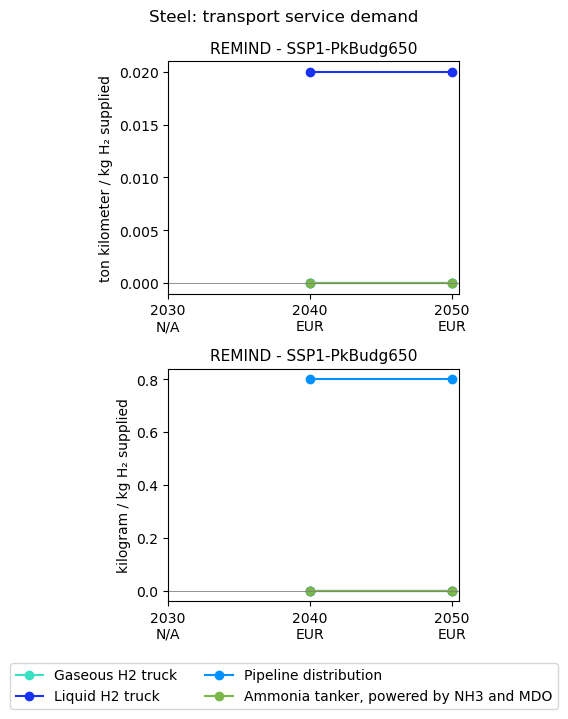

In [200]:
def year_labels(scenario):
    locations = selection.loc[selection["scenario"] == scenario].set_index("year").reindex(YEARS)
    return [f"{year}\n{locations.loc[year, 'location'] if pd.notna(locations.loc[year, 'location']) else 'N/A'}" for year in YEARS]

def available_years(scenario):
    return available.loc[available["scenario"] == scenario, "year"].tolist()

if activities.empty:
    print("No mapped transport service demands in the selected markets.")
else:
    activity_units = activities["provider unit"].drop_duplicates().tolist()
    fig, axes = plt.subplots(len(activity_units), len(labels), squeeze=False,
                             figsize=(4 * len(labels), 3.3 * len(activity_units)),
                             sharey="row")
    for row, unit in enumerate(activity_units):
        for col, scenario in enumerate(labels):
            ax = axes[row, col]
            for mode in mode_order:
                part = activities.loc[(activities["scenario"] == scenario)
                    & (activities["provider unit"] == unit) & (activities["component"] == mode)]
                values = part.groupby("year")["demand amount"].sum().reindex(YEARS, fill_value=0.0)
                values.loc[~values.index.isin(available_years(scenario))] = np.nan
                ax.plot(range(len(YEARS)), values, marker="o", label=mode, color=mode_colors[mode])
            ax.set_title(scenario)
            ax.set_xticks(range(len(YEARS)), year_labels(scenario))
            if col == 0:
                ax.set_ylabel(f"{unit} / kg H₂ supplied")
            ax.axhline(0, color="0.5", lw=0.6)
    handles, legend_labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, loc="upper center", bbox_to_anchor=(0.5, 0), ncol=2)
    fig.suptitle(f"{SECTOR}: transport service demand")
    fig.tight_layout()
    plt.show()


## 5. Absolute transport impacts

One 16:9 figure per model/scenario, with all ten impact categories in a 2 × 5 grid. The title includes the mapped warming label, sector and preferred region. Years appear below each panel. Categories retain the same limits across scenarios. Colors/hatches identify transport modes, diamonds show signed totals, and N/A indicates missing markets. Actual selected regions remain available in the selection table.


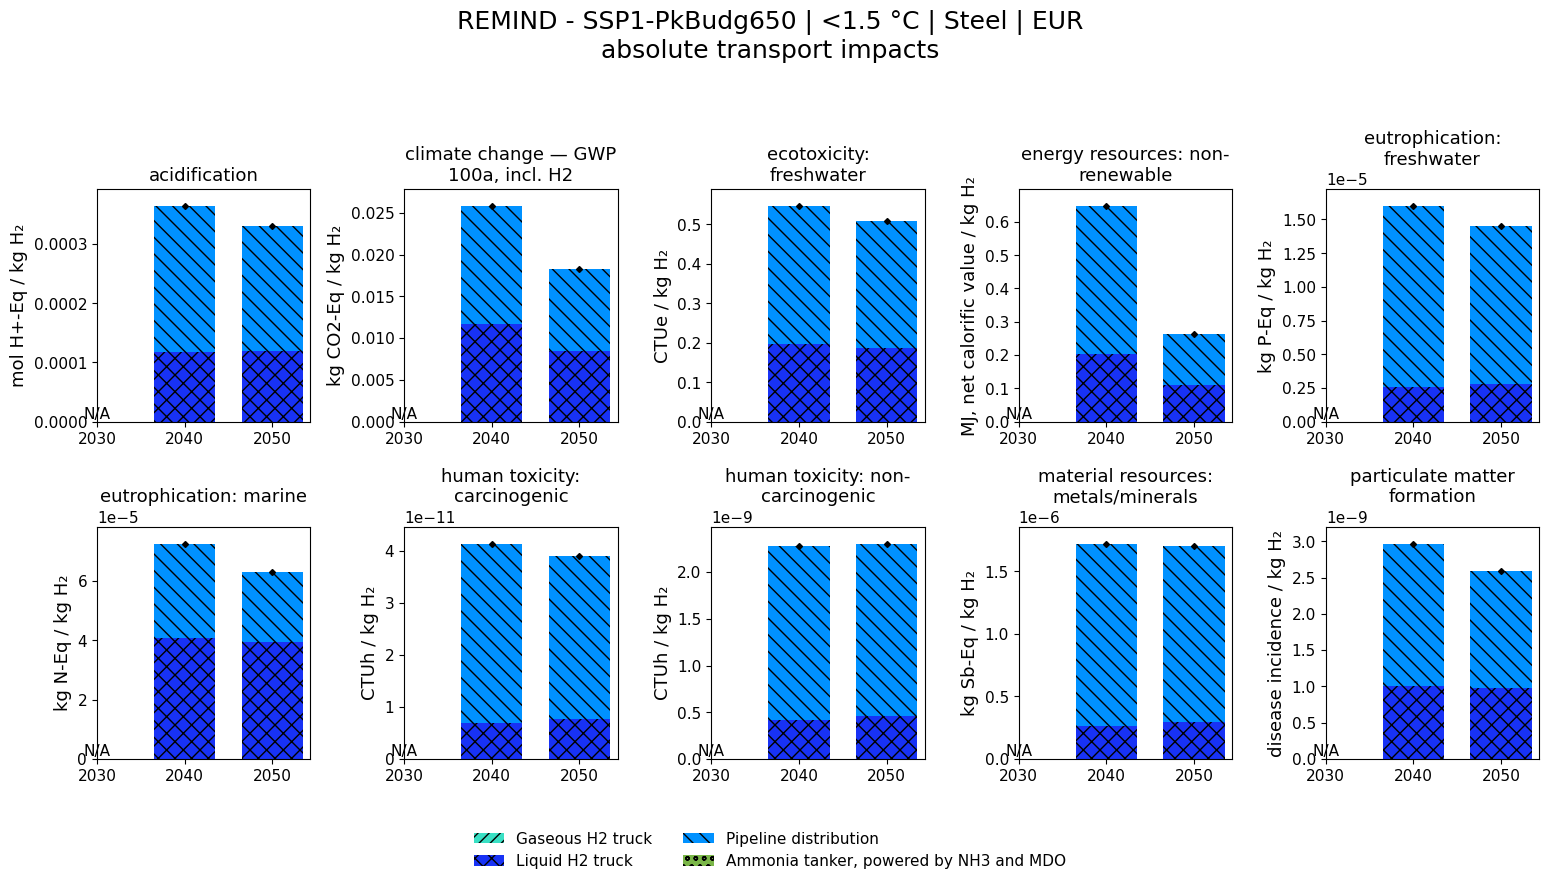

In [201]:
def plot_stacks(frame, group_column, groups, colors, hatches, title):
    # Match the spider/contribution notebook typography, locally to these figures.
    style = {"font.family": "sans-serif", "font.size": 15,
             "axes.titlesize": 13, "axes.labelsize": 13,
             "xtick.labelsize": 11, "ytick.labelsize": 11,
             "legend.fontsize": 11, "legend.title_fontsize": 12,
             "figure.titlesize": 18}
    # All categories share one 16:9 figure per scenario.
    with plt.rc_context(style):
        for scenario in labels:
            scenario_key = next(key for key, label in scenario_labels.items() if label == scenario)
            warming = mapping.WARMING_MAP[scenario_key]
            fig, axes = plt.subplots(math.ceil(len(categories) / 5), 5, figsize=(16, 9), squeeze=False)
            x = np.arange(len(YEARS))
            exists = np.array([y in available_years(scenario) for y in YEARS])
            for ax, category in zip(axes.flat, categories):
                # Shared category limits across scenarios preserve comparability.
                part = frame.loc[frame["impact category"] == category]
                all_values = part.groupby(["scenario", "year", group_column])["score"].sum().unstack(group_column)
                positions = [(s, y) for s in labels for y in YEARS]
                all_values = all_values.reindex(pd.MultiIndex.from_tuples(
                    positions, names=["scenario", "year"]))
                all_values = all_values.reindex(columns=groups).fillna(0.0)
                low = min(0.0, float(all_values.clip(upper=0).sum(axis=1).min()))
                high = max(0.0, float(all_values.clip(lower=0).sum(axis=1).max()))
                padding = 0.08 * (high - low) if high > low else 0.05
                pivot = all_values.loc[scenario].reindex(YEARS)
                positive, negative = np.zeros(len(x)), np.zeros(len(x))
                for group in groups:
                    values = pivot[group].to_numpy()
                    bottom = np.where(values >= 0, positive, negative)
                    ax.bar(x, np.where(exists, values, np.nan), bottom=bottom,
                           color=colors[group], hatch=hatches.get(group, ""),
                           label=group, width=0.7)
                    positive += np.maximum(values, 0)
                    negative += np.minimum(values, 0)
                ax.plot(x, np.where(exists, pivot.sum(axis=1), np.nan), "kD", ms=3)
                ax.set_ylim(low - padding if low < 0 else 0, high + padding)
                for i in np.flatnonzero(~exists):
                    ax.text(i, 0, "N/A", ha="center", va="bottom", fontsize=11)
                ax.set_xticks(x, [str(y) for y in YEARS])
                # Wrap category titles to fit the five-column layout.
                from textwrap import fill
                ax.set_title(fill(category, width=22))
                ax.set_ylabel(f"{units[category]} / kg H₂")
                ax.axhline(0, color="0.4", lw=0.6)
            for ax in list(axes.flat)[len(categories):]:
                ax.set_visible(False)
            handles, legend_labels = axes.flat[0].get_legend_handles_labels()
            fig.legend(handles, legend_labels, loc="lower center",
                       bbox_to_anchor=(0.5, 0.015), ncol=2, frameon=False)
            fig.suptitle(f"{scenario} | {warming} | {SECTOR} | {REGION}\n{title}",
                         y=0.985)
            # Keep the title close to the panels; the legend stays within the canvas.
            fig.tight_layout(rect=(0.005, 0.10, 0.995, 0.96), h_pad=1.0, w_pad=0.8)
            plt.show()

plot_stacks(transport, "process", mode_order, mode_colors, mode_hatches,
            "absolute transport impacts")


## 6. Transport impact relative to 2030

Each scenario has its own baseline. These ratios compare changes, not absolute performance between scenarios or importance between categories. Consult the absolute view above, especially for very small positive baselines. All panels share one scale; negative results are preserved.

Bars start at 1.0: decreases extend left and increases extend right. Endpoints show the normalized impact, with a common axis centered on 1.0.


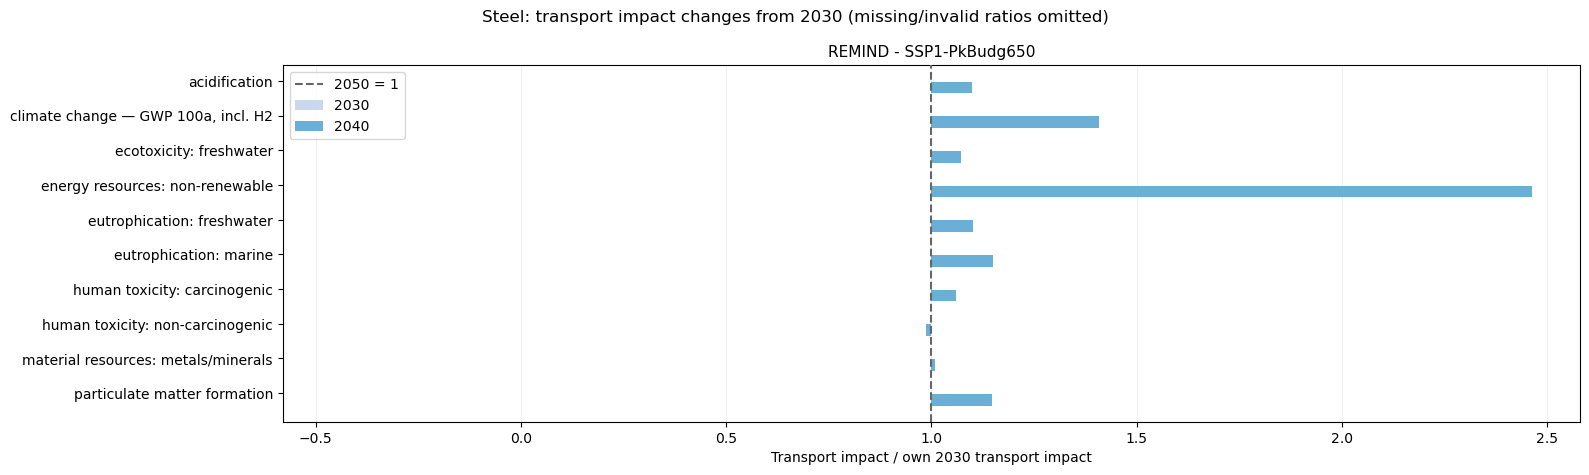

In [202]:
fig, axes = plt.subplots(math.ceil(len(labels) / 3), min(3, len(labels)),
                         squeeze=False, sharex=True, sharey=True,
                         figsize=(16, 4.8 * math.ceil(len(labels) / 3)))
plot_years = [year for year in YEARS if year != BASE_YEAR]
bar_height = 0.75 / max(1, len(plot_years))
# Signed widths start at the baseline, as in the master notebook's barh pattern.
# Use symmetric limits so 1.0 stays in the middle of every scenario panel.
ratios = totals.loc[totals["year"].isin(plot_years), "normalized"].to_numpy(dtype=float)
finite_ratios = ratios[np.isfinite(ratios)]
half_range = max(0.1, float(np.max(np.abs(finite_ratios - 1.0))) * 1.08) if finite_ratios.size else 0.1
for ax, scenario in zip(axes.flat, labels):
    subset = totals.loc[totals["scenario"] == scenario]
    for i, year in enumerate(plot_years):
        values = subset.loc[subset["year"] == year].set_index("impact category")
        values = values.reindex(categories)["normalized"]
        offset = (i - (len(plot_years) - 1) / 2) * bar_height
        ax.barh(np.arange(len(categories)) + offset, values - 1.0, left=1.0,
                height=bar_height * 0.9,
                color=mapping.YEAR_COLORS.get(year, "black"), label=str(year), zorder=2)
    ax.axvline(1, color="0.4", ls="--", label=f"{BASE_YEAR} = 1", zorder=3)
    ax.set_title(scenario)
    ax.set_yticks(range(len(categories)), categories)
    ax.set_xlabel("Transport impact / own 2030 transport impact")
    ax.grid(axis="x", alpha=0.2, zorder=0)
    ax.set_xlim(1.0 - half_range, 1.0 + half_range)
    ax.legend()
axes.flat[0].invert_yaxis()
for ax in list(axes.flat)[len(labels):]:
    ax.set_visible(False)
fig.suptitle(f"{SECTOR}: transport impact changes from 2030 (missing/invalid ratios omitted)")
fig.tight_layout()
plt.show()


## 7. Companion view: transport, conditioning and leakage

This shows whether a reduction in transport-service impacts is accompanied by higher conversion/reconversion impacts. Leakage is kept separate and includes mapped direct market leakage; it is not automatically assigned to a transport mode. Production remains excluded. See the selection and reconciliation tables before interpreting changes.

Run section 5 first after editing plot settings: it defines the shared plotting function used here. Both sections show all impact categories together in one figure per scenario.


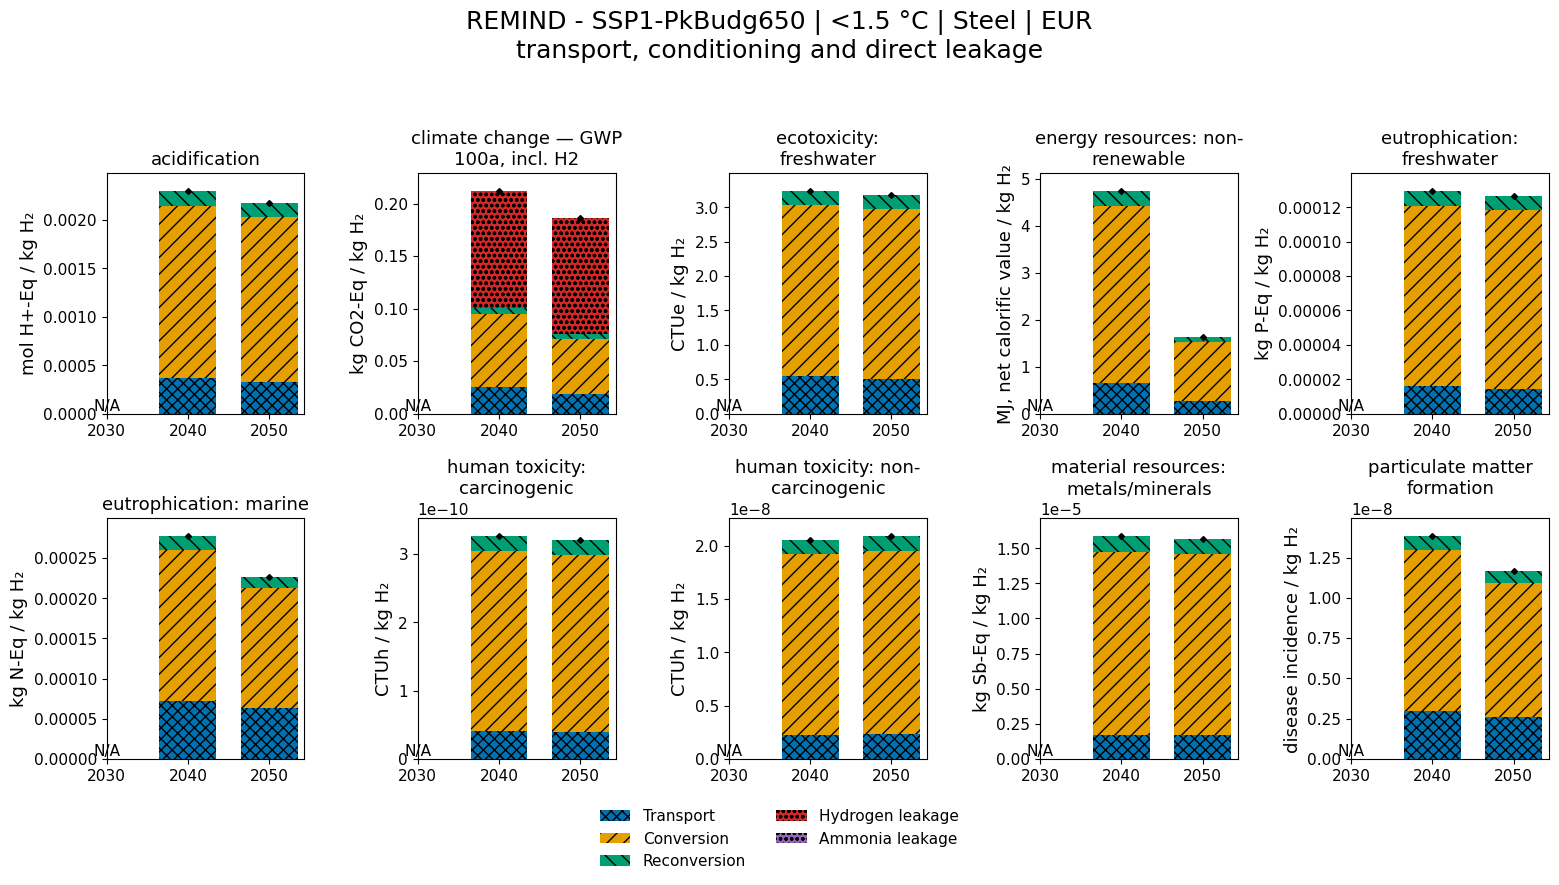

In [203]:
companion = distribution.copy()
companion["group"] = np.where(
    companion["contribution type"].isin(mapping.LEAKAGE_CONTRIBUTION_TYPES),
    companion["contribution type"], companion["substage"])
groups = ["Transport", "Conversion", "Reconversion", *mapping.LEAKAGE_CONTRIBUTION_TYPES]
colors = dict(zip(groups[:3], cfg.ACCESSIBLE_CATEGORICAL_COLORS[:3]))
colors.update(mapping.LEAKAGE_COLORS)
hatches = {"Transport": mapping.PROCESS_HATCH["Distribution"],
           "Conversion": mapping.PROCESS_HATCH["Conversion"],
           "Reconversion": mapping.PROCESS_HATCH["Reconversion"],
           **{g: mapping.PROCESS_HATCH["Hydrogen leakage"]
              for g in mapping.LEAKAGE_CONTRIBUTION_TYPES}}
plot_stacks(companion, "group", groups, colors, hatches,
            "transport, conditioning and direct leakage")


## 8. Transport-distance sensitivity (−50% / +50%)

One mode's distance changes at a time; mode shares remain fixed. Gaseous and liquid hydrogen trucks are separate. Labels show the baseline and absolute tested distances in km. Defaults must match the distances used to build the selected database; edit them below if necessary.

This uses `lcia_transport_distance_sensitivity.InMemoryDistanceModel`, changing copies of Brightway matrices without saving exchanges. Truck/ship transport-service demand scales with distance. The **pipeline baseline is 500 km (250 + 250 km)** in `lci-hydrogen-heating.xlsx`. Its sensitivity scales pipe/compressor infrastructure, transmission/distribution compression electricity, transmission leakage and replacement hydrogen. Storage infrastructure, storage compression electricity and storage losses stay fixed. Thus pipeline conversion and losses change here, unlike the share sensitivity in section 9.

Because the pipeline case includes these additional effects, the plots report **change in the full sector-market LCIA score**, not just the transport subtotal. Absolute baseline and varied scores remain in the results table, per kg H₂. Zero/negative baselines have no percentage bars. Calculations can take time: each impact method requires matrix solves for the active modes and distance cases.


In [206]:
DISTANCE_SCENARIO = labels[0]
DISTANCE_YEAR = 2050
DISTANCE_CHANGES = (-0.5, 0.5)

# Read only literal configuration constants; do not import Premise or its dependencies.
import ast
hydrogen_source = ANALYSIS_DIR.parent.parent / "premise" / "fuels" / "hydrogen.py"
constant_names = {
    "HYDROGEN_TRANSPORT_ACTIVITIES", "HYDROGEN_TRANSPORT_DISTANCES_KM",
    "HYDROGEN_PIPELINE_GENERAL_MARKET_AMOUNT", "KG_TO_TONNE",
}
source_tree = ast.parse(hydrogen_source.read_text(encoding="utf-8"))
transport_constants = {
    target.id: ast.literal_eval(node.value)
    for node in source_tree.body if isinstance(node, ast.Assign)
    for target in node.targets
    if isinstance(target, ast.Name) and target.id in constant_names
}
if set(transport_constants) != constant_names:
    raise ValueError(f"Missing transport constants in {hydrogen_source}")
HYDROGEN_TRANSPORT_ACTIVITIES = transport_constants["HYDROGEN_TRANSPORT_ACTIVITIES"]
HYDROGEN_TRANSPORT_DISTANCES_KM = transport_constants["HYDROGEN_TRANSPORT_DISTANCES_KM"]
HYDROGEN_PIPELINE_GENERAL_MARKET_AMOUNT = transport_constants["HYDROGEN_PIPELINE_GENERAL_MARKET_AMOUNT"]
KG_TO_TONNE = transport_constants["KG_TO_TONNE"]
# Shared source constants avoid importing the Premise package.
DISTANCE_BASELINE_KM = {
    mapping.TRANSPORT_NAMES[item["name"]]: (
        500.0 if mode == "compressed_gaseous_pipeline"
        else float(HYDROGEN_TRANSPORT_DISTANCES_KM[mode]))
    for mode, item in HYDROGEN_TRANSPORT_ACTIVITIES.items()
    if item["name"] in mapping.TRANSPORT_NAMES
}
# Edit DISTANCE_BASELINE_KM here for inventories built with different distances.
distance_cases = pd.DataFrame([
    {"mode": mode, "−50% (km)": distance * 0.5,
     "baseline (km)": distance, "+50% (km)": distance * 1.5}
    for mode, distance in DISTANCE_BASELINE_KM.items()])
display(distance_cases)


,mode,−50% (km),baseline (km),+50% (km)
0,Gaseous H2 truck,25.0,50.0,75.0
1,Liquid H2 truck,50.0,100.0,150.0
2,Pipeline distribution,250.0,500.0,750.0
3,"Ammonia tanker, powered by NH3 and MDO",1250.0,2500.0,3750.0


In [207]:
helper_dir = ANALYSIS_DIR / "notebooks"
if str(helper_dir) not in sys.path:
    sys.path.insert(0, str(helper_dir))
from lcia_transport_distance_sensitivity import (
    DistanceMode, InMemoryDistanceModel, direct_mode_amount, mode_audit,
)
if bd.projects.current != PROJECT:
    raise RuntimeError("Switch back to the analysis project before running distance sensitivity.")
distance_selection = selection.loc[
    (selection["scenario"] == DISTANCE_SCENARIO)
    & (selection["year"] == DISTANCE_YEAR) & (selection["status"] == "available")]
if len(distance_selection) != 1:
    raise ValueError("Choose an available scenario/year from the selection table.")
distance_market = bd.get_activity(distance_selection.iloc[0]["activity_key"])
distance_modes, distance_status = [], []
for name, label in mapping.TRANSPORT_NAMES.items():
    baseline_km = DISTANCE_BASELINE_KM[label]
    if not np.isfinite(baseline_km) or baseline_km <= 0:
        raise ValueError(f"Invalid baseline distance for {label}.")
    amount = direct_mode_amount(distance_market, name)
    distance_status.append({"mode": label, "status": "active" if amount > 0 else "inactive",
                            "baseline (km)": baseline_km})
    if amount <= 0:
        continue
    distance_modes.append(DistanceMode(
        label=label, activity_name=name, baseline_km=baseline_km,
        higher_distances_km=tuple(baseline_km * (1 + change) for change in DISTANCE_CHANGES),
        market_labels=(SECTOR,),
        kind="pipeline" if name == mapping.PIPELINE_TRANSPORT_ACTIVITY_NAME else "tonne-kilometre",
    ))
display(pd.DataFrame(distance_status))
if not distance_modes:
    raise ValueError("No active mapped transport modes in this market.")
display(mode_audit({SECTOR: distance_market}, distance_modes))

distance_frames = []
for method in methods:
    print(f"Distance sensitivity: {mapping.impact_category_label(method)}")
    model = InMemoryDistanceModel({SECTOR: distance_market}, method)
    result = model.run(distance_modes, method_units[method])
    # Keep the exact method and geographic context with every score.
    result["method"] = [method] * len(result)
    result["impact category"] = mapping.impact_category_label(method)
    result["model/scenario"] = DISTANCE_SCENARIO
    result["year"] = DISTANCE_YEAR
    result.loc[result["baseline score per kg H2"] <= 0, "change (%)"] = np.nan
    distance_frames.append(result)
    del model

distance_results = pd.concat(distance_frames, ignore_index=True)
display(distance_results[["transport mode", "impact category", "distance (km)",
                          "baseline score per kg H2", "score per kg H2",
                          "absolute change", "change (%)", "unit"]])


,mode,status,baseline (km)
0,Gaseous H2 truck,inactive,50.0
1,Liquid H2 truck,active,100.0
2,Pipeline distribution,active,500.0
3,"Ammonia tanker, powered by NH3 and MDO",inactive,2500.0


,transport mode,market,market location,baseline distance (km),direct exchange amount,exchange unit,direct transport share
0,Liquid H2 truck,Steel,EUR,100.0,0.02,ton kilometer,0.2
1,Pipeline distribution,Steel,EUR,500.0,0.80,kilogram,0.8


Distance sensitivity: acidification


c:\Users\ac145674\AppData\Local\anaconda3\envs\brightway25\Lib\site-packages\bw2calc\lca_base.py:125: UserWarning: PARDISO installed; this is a no-op
  warnings.warn("PARDISO installed; this is a no-op")
c:\Users\ac145674\AppData\Local\anaconda3\envs\brightway25\Lib\site-packages\bw2calc\lca_base.py:125: UserWarning: PARDISO installed; this is a no-op
  warnings.warn("PARDISO installed; this is a no-op")


Distance sensitivity: climate change — GWP 100a, incl. H2


...

Distance sensitivity: material resources: metals/minerals


c:\Users\ac145674\AppData\Local\anaconda3\envs\brightway25\Lib\site-packages\bw2calc\lca_base.py:125: UserWarning: PARDISO installed; this is a no-op
  warnings.warn("PARDISO installed; this is a no-op")
c:\Users\ac145674\AppData\Local\anaconda3\envs\brightway25\Lib\site-packages\bw2calc\lca_base.py:125: UserWarning: PARDISO installed; this is a no-op
  warnings.warn("PARDISO installed; this is a no-op")


Distance sensitivity: particulate matter formation


c:\Users\ac145674\AppData\Local\anaconda3\envs\brightway25\Lib\site-packages\bw2calc\lca_base.py:125: UserWarning: PARDISO installed; this is a no-op
  warnings.warn("PARDISO installed; this is a no-op")
c:\Users\ac145674\AppData\Local\anaconda3\envs\brightway25\Lib\site-packages\bw2calc\lca_base.py:125: UserWarning: PARDISO installed; this is a no-op
  warnings.warn("PARDISO installed; this is a no-op")


,transport mode,impact category,distance (km),baseline score per kg H2,score per kg H2,absolute change,change (%),unit
0,Liquid H2 truck,acidification,100.0,2.575967e-02,2.575967e-02,0.000000e+00,0.000000,mol H+-Eq
1,Liquid H2 truck,acidification,50.0,2.575967e-02,2.570037e-02,-5.930854e-05,-0.230238,mol H+-Eq
2,Liquid H2 truck,acidification,150.0,2.575967e-02,2.581898e-02,5.930855e-05,0.230238,mol H+-Eq
3,Pipeline distribution,acidification,500.0,2.575967e-02,2.575967e-02,0.000000e+00,0.000000,mol H+-Eq
4,Pipeline distribution,acidification,250.0,2.575967e-02,2.554018e-02,-2.194911e-04,-0.852073,mol H+-Eq
5,Pipeline distribution,acidification,750.0,2.575967e-02,2.597918e-02,2.195088e-04,0.852141,mol H+-Eq
6,Liquid H2 truck,"climate change — GWP 100a, incl. H2",100.0,7.986093e-01,7.986093e-01,0.000000e+00,0.000000,kg CO2-Eq
7,Liquid H2 truck,"climate change — GWP 100a, incl. H2",50.0,7.986093e-01,7.925985e-01,-6.010806e-03,-0.752659,kg CO2-Eq
8,Liquid H2 truck,"climate change — GWP 100a, incl. H2",150.0,7.986093e-01,8.046201e-01,6.010807e-03,0.752659,kg CO2-Eq
9,Pipeline distribution,"climate change — GWP 100a, incl. H2",500.0,7.986093e-01,7.986093e-01,0.000000e+00,0.000000,kg CO2-Eq


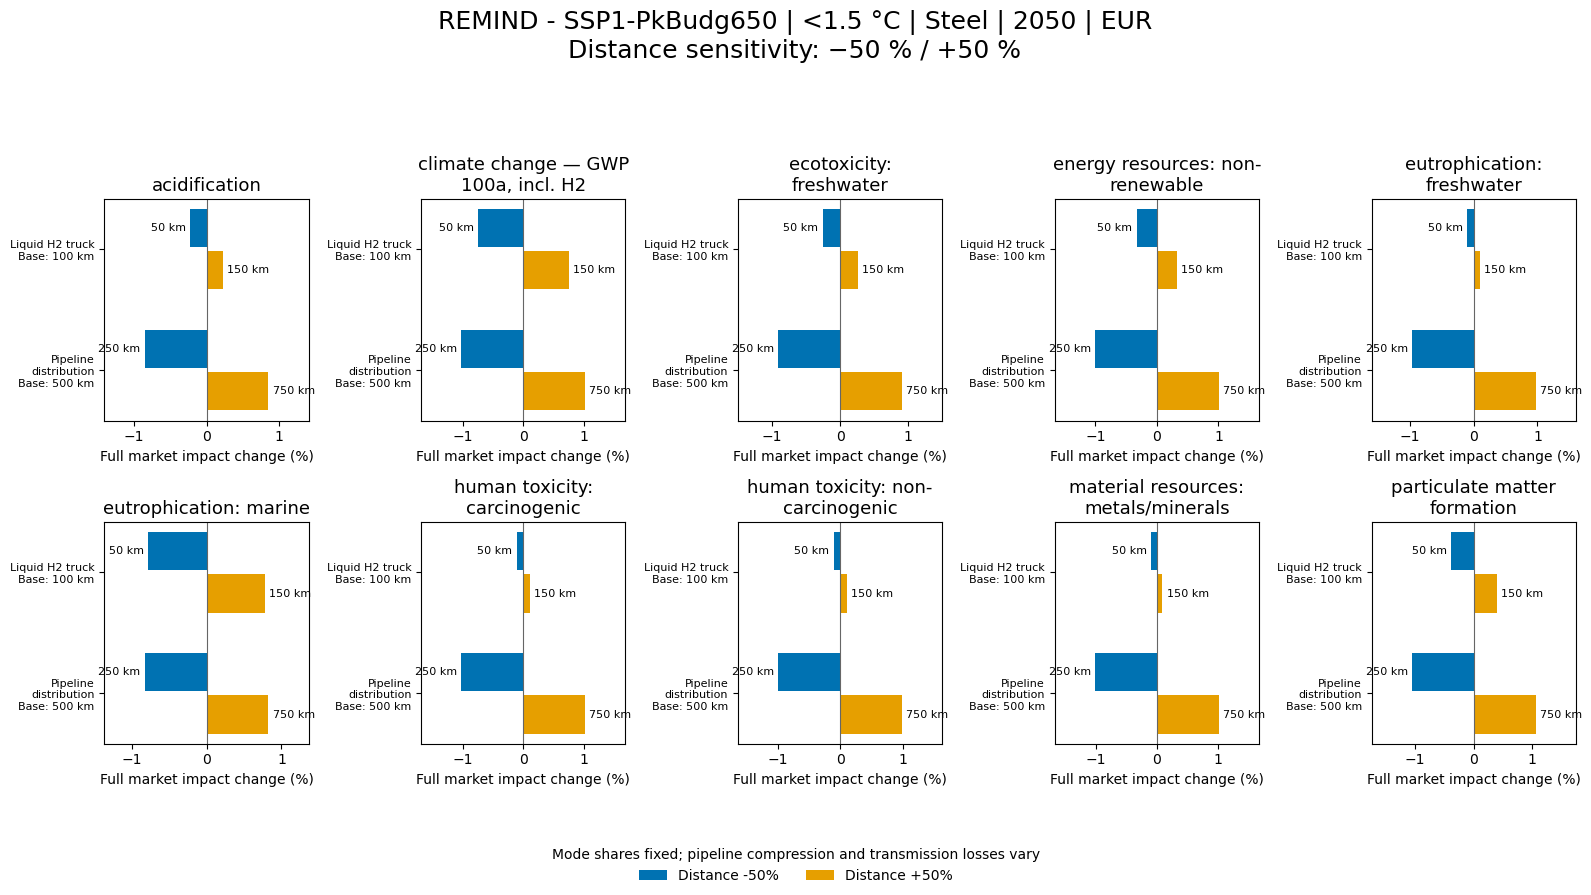

In [208]:
from textwrap import fill
active_modes = [mode.label for mode in distance_modes]
fig, axes = plt.subplots(math.ceil(len(categories) / 5), 5, figsize=(16, 9), squeeze=False)
bar_height = 0.7 / len(DISTANCE_CHANGES)
for ax, category in zip(axes.flat, categories):
    part = distance_results.loc[distance_results["impact category"] == category]
    for i, change in enumerate(DISTANCE_CHANGES):
        varied = part.loc[np.isclose(part["distance multiplier"], 1 + change)].set_index("transport mode")
        values = varied["change (%)"].reindex(active_modes)
        offset = (i - (len(DISTANCE_CHANGES) - 1) / 2) * bar_height
        bars = ax.barh(np.arange(len(active_modes)) + offset, values,
                       height=bar_height * 0.9, color=cfg.ACCESSIBLE_CATEGORICAL_COLORS[i],
                       label=f"Distance {change:+.0%}")
        # Absolute distances printed beside each bar, including zero-impact cases.
        for bar, mode, value in zip(bars, active_modes, values):
            if not np.isfinite(value):
                continue
            km = DISTANCE_BASELINE_KM[mode] * (1 + change)
            ax.annotate(f"{km:g} km", (value, bar.get_y() + bar.get_height()/2),
                        xytext=(3 if value >= 0 else -3, 0), textcoords="offset points",
                        ha="left" if value >= 0 else "right", va="center", fontsize=8)
    changes = part.loc[~np.isclose(part["distance multiplier"], 1), "change (%)"].dropna()
    extent = max(1.0, float(changes.abs().max()) * 1.65) if not changes.empty else 1.0
    ax.set_xlim(-extent, extent)
    ax.axvline(0, color="0.4", lw=0.8)
    ax.set_yticks(range(len(active_modes)),
                 [fill(mode, 18) + f"\nBase: {DISTANCE_BASELINE_KM[mode]:g} km" for mode in active_modes],
                 fontsize=8)
    ax.invert_yaxis()
    ax.set_title(fill(category, 22), fontsize=13)
    ax.set_xlabel("Full market impact change (%)", fontsize=10)
    if changes.empty:
        ax.text(.5, .5, "No valid percentage changes", transform=ax.transAxes, ha="center", fontsize=8)
for ax in list(axes.flat)[len(categories):]:
    ax.set_visible(False)
handles, legend_labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="lower center", ncol=2, frameon=False,
           title="Mode shares fixed; pipeline compression and transmission losses vary")
key = next(key for key, label in scenario_labels.items() if label == DISTANCE_SCENARIO)
fig.suptitle(f"{DISTANCE_SCENARIO} | {mapping.WARMING_MAP[key]} | {SECTOR} | {DISTANCE_YEAR} | {distance_selection.iloc[0]['location']}\nDistance sensitivity: −50 % / +50 %", fontsize=18)
fig.tight_layout(rect=(0, .10, 1, .91), w_pad=1)
plt.show()


### Distance sensitivity relative to distribution

The additional plot divides the distance-induced absolute impact change by baseline **distribution impact** (transport, conversion/reconversion and direct leakage). Production is excluded from the denominator. The pipeline numerator retains the helper’s induced compression and loss-replacement effects. This is a distribution-normalized sensitivity, not a new stage decomposition of every modified inventory. The full-market plot above remains available.


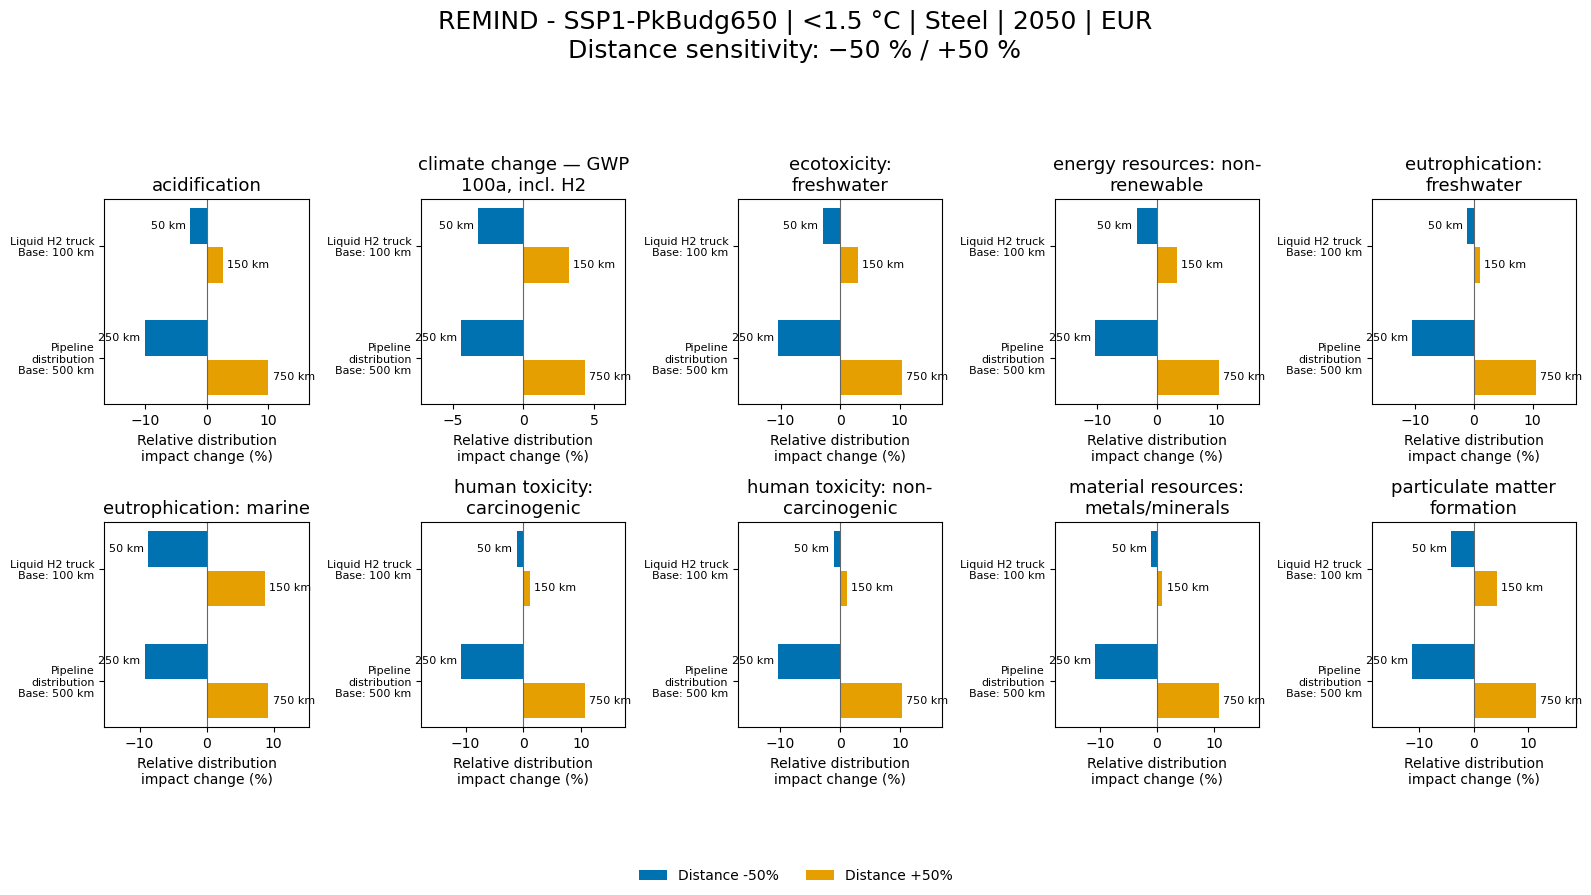

In [209]:
# Normalize distance-induced changes to the baseline distribution subtotal.
# This subtotal includes transport, conditioning/reconversion and direct leakage.
distance_distribution_baseline = distribution.loc[
    (distribution["scenario"] == DISTANCE_SCENARIO)
    & (distribution["year"] == DISTANCE_YEAR)
].groupby("impact category")["score"].sum()
distance_distribution_results = distance_results.copy()
distance_distribution_results["baseline distribution"] = distance_distribution_results[
    "impact category"].map(distance_distribution_baseline)
denominator = distance_distribution_results["baseline distribution"]
distance_distribution_results["relative distribution impact change (%)"] = (
    100 * distance_distribution_results["absolute change"]
    / denominator.where(np.isfinite(denominator) & (denominator > 0)))

from textwrap import fill
active_modes = [mode.label for mode in distance_modes]
fig, axes = plt.subplots(math.ceil(len(categories) / 5), 5, figsize=(16, 9), squeeze=False)
bar_height = 0.7 / len(DISTANCE_CHANGES)
for ax, category in zip(axes.flat, categories):
    part = distance_distribution_results.loc[distance_results["impact category"] == category]
    for i, change in enumerate(DISTANCE_CHANGES):
        varied = part.loc[np.isclose(part["distance multiplier"], 1 + change)].set_index("transport mode")
        values = varied["relative distribution impact change (%)"].reindex(active_modes)
        offset = (i - (len(DISTANCE_CHANGES) - 1) / 2) * bar_height
        bars = ax.barh(np.arange(len(active_modes)) + offset, values,
                       height=bar_height * 0.9, color=cfg.ACCESSIBLE_CATEGORICAL_COLORS[i],
                       label=f"Distance {change:+.0%}")
        # Absolute distances printed beside each bar, including zero-impact cases.
        for bar, mode, value in zip(bars, active_modes, values):
            if not np.isfinite(value):
                continue
            km = DISTANCE_BASELINE_KM[mode] * (1 + change)
            ax.annotate(f"{km:g} km", (value, bar.get_y() + bar.get_height()/2),
                        xytext=(3 if value >= 0 else -3, 0), textcoords="offset points",
                        ha="left" if value >= 0 else "right", va="center", fontsize=8)
    changes = part.loc[~np.isclose(part["distance multiplier"], 1), "relative distribution impact change (%)"].dropna()
    extent = max(1.0, float(changes.abs().max()) * 1.65) if not changes.empty else 1.0
    ax.set_xlim(-extent, extent)
    ax.axvline(0, color="0.4", lw=0.8)
    ax.set_yticks(range(len(active_modes)),
                 [fill(mode, 18) + f"\nBase: {DISTANCE_BASELINE_KM[mode]:g} km" for mode in active_modes],
                 fontsize=8)
    ax.invert_yaxis()
    ax.set_title(fill(category, 22), fontsize=13)
    ax.set_xlabel("Relative distribution\nimpact change (%)", fontsize=10)
    if changes.empty:
        ax.text(.5, .5, "No valid percentage changes", transform=ax.transAxes, ha="center", fontsize=8)
for ax in list(axes.flat)[len(categories):]:
    ax.set_visible(False)
handles, legend_labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, legend_labels, loc="lower center", ncol=2, frameon=False)
           #title="Mode shares fixed; pipeline compression and transmission losses vary")
key = next(key for key, label in scenario_labels.items() if label == DISTANCE_SCENARIO)
fig.suptitle(f"{DISTANCE_SCENARIO} | {mapping.WARMING_MAP[key]} | {SECTOR} | {DISTANCE_YEAR} | {distance_selection.iloc[0]['location']}\nDistance sensitivity: −50 % / +50 %", fontsize=18)
fig.tight_layout(rect=(0, .10, 1, .91), w_pad=1)
plt.show()


## 9. Complete delivery-route share sensitivity

Each active route is varied independently by −50% and +50% of its baseline share. Other active route shares adjust proportionally to keep the distributed fraction at 100%. Gaseous and liquid H₂ trucks are separate routes. The undistributed fraction stays fixed.

**Transport, conversion, reconversion and attributable leakage scale together** by new share / baseline share. The route families come from `LCIA_mapping_h2.py`. The allocation audit must reconstruct all baseline distribution impacts. Nonzero market-level leakage with no unique route requires a documented allocation in the settings; it is never silently held fixed or assigned arbitrarily.

The x-axis is **relative distribution impact change (%)**, using the complete baseline distribution subtotal. Distances and technology intensities remain fixed. Upstream replacement-hydrogen burdens already embedded in route services (including pipeline/regasification loss compensation) scale with those services and are not added a second time. The main hydrogen production mix is unchanged. An explicit allocation of standalone market leakage does not create new replacement-hydrogen exchanges; those must already be represented by the modeled route inventories for a fully loss-balanced interpretation.

Physical shares use the inverse of the sector-market builder's distance factors. Verify these against the database construction assumptions. Inactive modes cannot be introduced by relative scaling; infeasible cases are listed. All results stay inline. Run the settings, calculation and plotting cells below after updating this section.


In [210]:
SENSITIVITY_SCENARIO = labels[0]  # Use a scenario label from the earlier tables.
SENSITIVITY_YEAR = 2050
SHARE_CHANGES = (-0.5, 0.5)

# Read only literal configuration constants; do not import Premise or its dependencies.
import ast
hydrogen_source = ANALYSIS_DIR.parent.parent / "premise" / "fuels" / "hydrogen.py"
constant_names = {
    "HYDROGEN_TRANSPORT_ACTIVITIES", "HYDROGEN_TRANSPORT_DISTANCES_KM",
    "HYDROGEN_PIPELINE_GENERAL_MARKET_AMOUNT", "KG_TO_TONNE",
}
source_tree = ast.parse(hydrogen_source.read_text(encoding="utf-8"))
transport_constants = {
    target.id: ast.literal_eval(node.value)
    for node in source_tree.body if isinstance(node, ast.Assign)
    for target in node.targets
    if isinstance(target, ast.Name) and target.id in constant_names
}
if set(transport_constants) != constant_names:
    raise ValueError(f"Missing transport constants in {hydrogen_source}")
HYDROGEN_TRANSPORT_ACTIVITIES = transport_constants["HYDROGEN_TRANSPORT_ACTIVITIES"]
HYDROGEN_TRANSPORT_DISTANCES_KM = transport_constants["HYDROGEN_TRANSPORT_DISTANCES_KM"]
HYDROGEN_PIPELINE_GENERAL_MARKET_AMOUNT = transport_constants["HYDROGEN_PIPELINE_GENERAL_MARKET_AMOUNT"]
KG_TO_TONNE = transport_constants["KG_TO_TONNE"]
# Service demand for a mode supplying 1 kg H2. Both trucks have their own factor.
SERVICE_AMOUNT_PER_KG = {
    mapping.TRANSPORT_NAMES[item["name"]]: (
        HYDROGEN_PIPELINE_GENERAL_MARKET_AMOUNT if mode == "compressed_gaseous_pipeline"
        else HYDROGEN_TRANSPORT_DISTANCES_KM[mode] * KG_TO_TONNE)
    for mode, item in HYDROGEN_TRANSPORT_ACTIVITIES.items()
    if item["name"] in mapping.TRANSPORT_NAMES
}
# Optional: edit individual factors here if database construction used other distances.
display(pd.Series(SERVICE_AMOUNT_PER_KG, name="service amount per kg H2 on route"))

# Only needed if nonzero leakage is recorded directly on a multi-route market.
# Supply documented allocation fractions by canonical mode label; do not guess.
# Example structure: {"Hydrogen leakage": {"Gaseous H2 truck": ..., "Pipeline distribution": ...}}
MARKET_LEAKAGE_ROUTE_SHARES = {}


Gaseous H2 truck                          0.05
Liquid H2 truck                           0.10
Pipeline distribution                     1.00
Ammonia tanker, powered by NH3 and MDO    2.50
Name: service amount per kg H2 on route, dtype: float64

In [211]:
from run_analysis import _reference_output_amount

chosen = selection.loc[(selection["scenario"] == SENSITIVITY_SCENARIO)
                       & (selection["year"] == SENSITIVITY_YEAR)
                       & (selection["status"] == "available")]
if len(chosen) != 1:
    raise ValueError("Choose one available scenario/year from the selection table.")
if bd.projects.current != PROJECT:
    raise RuntimeError("Switch back to the analysis project before running sensitivity.")
market = bd.get_activity(chosen.iloc[0]["activity_key"])
reference_amount = _reference_output_amount(market)
direct_demand = pd.Series(0.0, index=mode_order)
for exchange in market.technosphere():
    provider = exchange.input
    name = provider.get("name", "")
    if name in mapping.TRANSPORT_NAMES:
        mode = mapping.TRANSPORT_NAMES[name]
        expected_unit = next(item["unit"] for item in HYDROGEN_TRANSPORT_ACTIVITIES.values()
                             if item["name"] == name)
        if provider.get("unit") != expected_unit:
            raise ValueError(f"Unexpected service unit for {mode}.")
        direct_demand[mode] += float(exchange["amount"]) / reference_amount

activity_subset = activities.loc[(activities["scenario"] == SENSITIVITY_SCENARIO)
                                & (activities["year"] == SENSITIVITY_YEAR)]
audit_demand = activity_subset.groupby("component")["demand amount"].sum().reindex(mode_order, fill_value=0)
if not np.allclose(direct_demand, audit_demand, rtol=cfg.RECONCILIATION_RTOL, atol=1e-12):
    raise ValueError("Nested transport branches found: direct market shares cannot safely represent this result.")
factors = pd.Series(SERVICE_AMOUNT_PER_KG).reindex(mode_order)
if factors.isna().any() or not np.isfinite(factors).all() or (factors <= 0).any():
    raise ValueError("Every transport mode needs a finite, positive per-share service factor.")
physical_shares = direct_demand / factors
if not np.isfinite(physical_shares).all() or (physical_shares < 0).any():
    raise ValueError("Recovered physical shares must be finite and nonnegative.")
distributed_fraction = float(physical_shares.sum())
if not 0 < distributed_fraction <= 1 + cfg.RECONCILIATION_RTOL:
    raise ValueError("Recovered shares must sum to >0 and <=1. Check database distance factors.")
baseline_shares = physical_shares / distributed_fraction
share_audit = pd.DataFrame({"service demand per kg H2": direct_demand,
                           "fraction of total H2": physical_shares,
                           "share within distributed H2 (%)": 100 * baseline_shares})
display(share_audit)
print(f"Distributed fraction: {distributed_fraction:.1%}; fixed undistributed remainder: {max(0, 1-distributed_fraction):.1%}")

# Allocate every distribution row to a complete delivery route, not transport alone.
selected_distribution = distribution.loc[
    (distribution["scenario"] == SENSITIVITY_SCENARIO)
    & (distribution["year"] == SENSITIVITY_YEAR)].copy()
family_modes = {}
for mode in mode_order:
    family_modes.setdefault(mapping.distribution_family(mode), []).append(mode)
active_modes = baseline_shares[baseline_shares > 0].index.tolist()
route_rows = []
for _, row in selected_distribution.iterrows():
    process = row["process"]
    is_market_leakage = process.endswith(" — market")
    if is_market_leakage:
        # A zero CF can hide a physically nonzero release: check both quantities.
        physical = row.get("physical amount", 0)
        nonzero = row["score"] != 0 or (pd.notna(physical) and physical != 0)
        if not nonzero:
            continue
        allocation = MARKET_LEAKAGE_ROUTE_SHARES.get(row["contribution type"])
        if allocation is None and len(active_modes) == 1:
            allocation = {active_modes[0]: 1.0}
        if allocation is None:
            raise ValueError(f"Cannot attribute {process}. Set a documented allocation in "
                             "MARKET_LEAKAGE_ROUTE_SHARES before varying complete routes.")
        if (not set(allocation).issubset(active_modes)
                or not all(np.isfinite(v) and v >= 0 for v in allocation.values())
                or not np.isclose(sum(allocation.values()), 1.0)):
            raise ValueError(f"Invalid route allocation for {process}.")
    else:
        family = mapping.distribution_family(process)
        matches = family_modes.get(family, [])
        if len(matches) != 1:
            raise ValueError(f"Cannot uniquely assign {process} to a delivery route: {matches}")
        allocation = {matches[0]: 1.0}
    for mode, fraction in allocation.items():
        item = row.to_dict()
        item.update({"route": mode, "allocation fraction": fraction,
                     "score": float(row["score"]) * fraction})
        if pd.notna(row.get("physical amount", np.nan)):
            item["physical amount"] = row["physical amount"] * fraction
        route_rows.append(item)
route_audit = pd.DataFrame(route_rows)
if route_audit.empty:
    raise ValueError("No distribution contributions could be assigned to routes.")
impact_by_mode = route_audit.groupby(["impact category", "route"])["score"].sum().unstack("route")
impact_by_mode = impact_by_mode.reindex(index=categories, columns=mode_order).fillna(0.0)
baseline_impact = selected_distribution.groupby("impact category")["score"].sum().reindex(categories)
if not np.allclose(impact_by_mode.sum(axis=1), baseline_impact,
                   rtol=cfg.RECONCILIATION_RTOL, atol=1e-12):
    raise AssertionError("Route contributions do not reconstruct baseline distribution impacts.")
for mode in mode_order:
    assigned = route_audit.loc[route_audit["route"] == mode]
    physical = assigned.get("physical amount", pd.Series(dtype=float)).fillna(0)
    if baseline_shares[mode] == 0 and (assigned["score"].ne(0).any() or physical.ne(0).any()):
        raise ValueError(f"Distribution contributions assigned to inactive route {mode}.")
display(route_audit[["route", "process", "substage", "contribution type",
                     "impact category", "score", "allocation fraction"]])

sensitivity_rows, case_rows, varied_share_rows = [], [], []
for mode in mode_order:
    for change in SHARE_CHANGES:
        case = f"{mode} {change:+.0%}"
        old = float(baseline_shares[mode])
        target = old * (1 + change)
        if old == 0:
            status = "Inactive mode: cannot introduce by relative scaling"
        elif old >= 1:
            status = "Only active mode: no other shares to redistribute"
        elif target < 0 or target > 1:
            status = "Infeasible target share"
        else:
            status = "OK"
        case_rows.append({"case": case, "status": status})
        if status != "OK":
            continue
        adjusted = baseline_shares * ((1 - target) / (1 - old))
        adjusted[mode] = target
        if (adjusted < 0).any() or not np.isclose(adjusted.sum(), 1.0):
            raise AssertionError("Adjusted shares do not form a valid distribution.")
        for other_mode, share in adjusted.items():
            varied_share_rows.append({"case": case, "mode": other_mode, "share (%)": 100 * share})
        scale = adjusted.div(baseline_shares.where(baseline_shares > 0)).fillna(0)
        new_impact = impact_by_mode.mul(scale, axis=1).sum(axis=1)
        for category in categories:
            base, result = float(baseline_impact[category]), float(new_impact[category])
            sensitivity_rows.append({"case": case, "varied mode": mode, "share change": change,
                "impact category": category, "baseline distribution": base,
                "distribution score": result, "absolute change": result - base,
                "relative distribution impact change (%)": 100 * (result / base - 1) if base > 0 else np.nan})
case_status = pd.DataFrame(case_rows)
sensitivity_results = pd.DataFrame(sensitivity_rows)
display(case_status)
if varied_share_rows:
    display(pd.DataFrame(varied_share_rows).pivot(index="case", columns="mode", values="share (%)"))
    display(sensitivity_results)
else:
    print("No feasible mode-share variations for this market.")


,service demand per kg H2,fraction of total H2,share within distributed H2 (%)
Gaseous H2 truck,0.00,0.0,0.0
Liquid H2 truck,0.02,0.2,20.0
Pipeline distribution,0.80,0.8,80.0
"Ammonia tanker, powered by NH3 and MDO",0.00,0.0,0.0


Distributed fraction: 100.0%; fixed undistributed remainder: 0.0%


,route,process,substage,contribution type,impact category,score,allocation fraction
0,Liquid H2 truck,Liquid H2 truck,Transport,Process excluding leakage,acidification,1.185962e-04,1.0
1,Liquid H2 truck,Hydrogen leakage — Liquid H2 truck,Transport,Hydrogen leakage,acidification,0.000000e+00,1.0
2,Pipeline distribution,Pipeline distribution,Transport,Process excluding leakage,acidification,2.120063e-04,1.0
3,Pipeline distribution,Compression (pipeline),Conversion,Process excluding leakage,acidification,3.138063e-08,1.0
4,Pipeline distribution,Compression (pipeline),Conversion,Process excluding leakage,acidification,6.326823e-04,1.0
...,...,...,...,...,...,...,...
95,Pipeline distribution,Hydrogen leakage — Pipeline distribution,Transport,Hydrogen leakage,particulate matter formation,0.000000e+00,1.0
96,Liquid H2 truck,Liquefaction,Conversion,Process excluding leakage,particulate matter formation,5.275323e-09,1.0
97,Liquid H2 truck,Hydrogen leakage — Liquefaction,Conversion,Hydrogen leakage,particulate matter formation,0.000000e+00,1.0
98,Liquid H2 truck,Liquid hydrogen regasification,Reconversion,Process excluding leakage,particulate matter formation,7.069823e-10,1.0


,case,status
0,Gaseous H2 truck -50%,Inactive mode: cannot introduce by relative sc...
1,Gaseous H2 truck +50%,Inactive mode: cannot introduce by relative sc...
2,Liquid H2 truck -50%,OK
3,Liquid H2 truck +50%,OK
4,Pipeline distribution -50%,OK
5,Pipeline distribution +50%,Infeasible target share
6,"Ammonia tanker, powered by NH3 and MDO -50%",Inactive mode: cannot introduce by relative sc...
7,"Ammonia tanker, powered by NH3 and MDO +50%",Inactive mode: cannot introduce by relative sc...


mode,"Ammonia tanker, powered by NH3 and MDO",Gaseous H2 truck,Liquid H2 truck,Pipeline distribution
case,,,,
Liquid H2 truck +50%,0.0,0.0,30.0,70.0
Liquid H2 truck -50%,0.0,0.0,10.0,90.0
Pipeline distribution -50%,0.0,0.0,60.0,40.0


,case,varied mode,share change,impact category,baseline distribution,distribution score,absolute change,relative distribution impact change (%)
0,Liquid H2 truck -50%,Liquid H2 truck,-0.5,acidification,2.179157e-03,1.617528e-03,-5.616283e-04,-25.772739
1,Liquid H2 truck -50%,Liquid H2 truck,-0.5,"climate change — GWP 100a, incl. H2",1.864585e-01,1.493211e-01,-3.713747e-02,-19.917282
2,Liquid H2 truck -50%,Liquid H2 truck,-0.5,ecotoxicity: freshwater,3.175807e+00,2.362748e+00,-8.130587e-01,-25.601642
3,Liquid H2 truck -50%,Liquid H2 truck,-0.5,energy resources: non-renewable,1.640546e+00,1.219974e+00,-4.205718e-01,-25.636085
4,Liquid H2 truck -50%,Liquid H2 truck,-0.5,eutrophication: freshwater,1.267745e-04,9.473973e-05,-3.203479e-05,-25.269108
5,Liquid H2 truck -50%,Liquid H2 truck,-0.5,eutrophication: marine,2.259993e-04,1.625626e-04,-6.343665e-05,-28.069404
6,Liquid H2 truck -50%,Liquid H2 truck,-0.5,human toxicity: carcinogenic,3.205764e-10,2.410958e-10,-7.948060e-11,-24.793029
7,Liquid H2 truck -50%,Liquid H2 truck,-0.5,human toxicity: non-carcinogenic,2.088404e-08,1.561939e-08,-5.264654e-09,-25.208981
8,Liquid H2 truck -50%,Liquid H2 truck,-0.5,material resources: metals/minerals,1.563887e-05,1.178774e-05,-3.851133e-06,-24.625386
9,Liquid H2 truck -50%,Liquid H2 truck,-0.5,particulate matter formation,1.165790e-08,8.761572e-09,-2.896323e-09,-24.844304


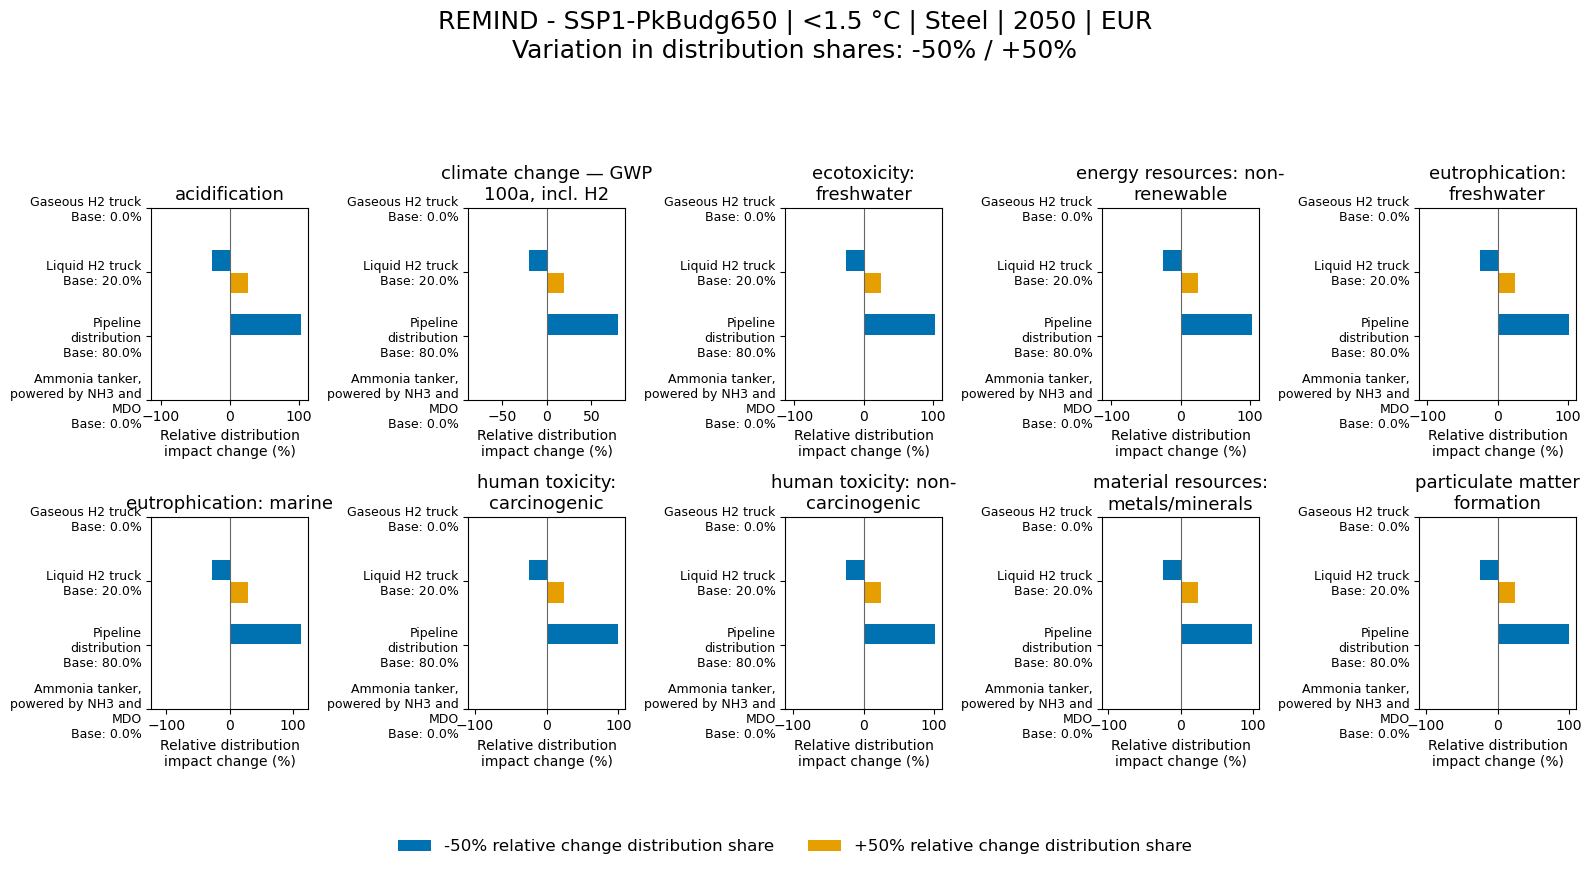

In [212]:
# A tornado-style view: each mode has separate -50% and +50% cases.
# Zero/negative impact baselines remain in the absolute table but have no % bars.
if not sensitivity_results.empty:
    from textwrap import fill
    fig, axes = plt.subplots(math.ceil(len(categories) / 5), 5, figsize=(16, 9), squeeze=False)
    bar_height = 0.7 / len(SHARE_CHANGES)
    for ax, category in zip(axes.flat, categories):
        part = sensitivity_results.loc[sensitivity_results["impact category"] == category]
        for i, change in enumerate(SHARE_CHANGES):
            values = part.loc[part["share change"] == change].set_index("varied mode")["relative distribution impact change (%)"].reindex(mode_order)
            offset = (i - (len(SHARE_CHANGES) - 1) / 2) * bar_height
            ax.barh(np.arange(len(mode_order)) + offset, values, height=bar_height * 0.9,
                    label=f"{change:+.0%} relative change distribution share",
                    color=cfg.ACCESSIBLE_CATEGORICAL_COLORS[i])
        finite = part["relative distribution impact change (%)"].dropna()
        extent = max(1, float(finite.abs().max()) * 1.1) if not finite.empty else 1
        ax.set_xlim(-extent, extent)
        ax.axvline(0, color="0.4", lw=0.8)
        ax.set_title(fill(category, 22), fontsize=13)
        ax.set_yticks(range(len(mode_order)), [fill(mode, 18) + f"\nBase: {100 * baseline_shares[mode]:.1f}%" for mode in mode_order], fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel("Relative distribution\nimpact change (%)", fontsize=10)
        if finite.empty:
            ax.text(0.5, 0.5, "No valid percentage changes", transform=ax.transAxes,
                    ha="center", fontsize=9)
    for ax in list(axes.flat)[len(categories):]:
        ax.set_visible(False)
    handles, legend_labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, legend_labels, loc="lower center", bbox_to_anchor=(0.5, 0.025),
               ncol=2, frameon=False, fontsize=12,)
               #title="Input variation (other mode shares adjusted to keep total = 100%)",
               #title_fontsize=12)
    key = next(key for key, label in scenario_labels.items() if label == SENSITIVITY_SCENARIO)
    change_label = " / ".join(f"{change:+.0%}" for change in SHARE_CHANGES)
    fig.suptitle(f"{SENSITIVITY_SCENARIO} | {mapping.WARMING_MAP[key]} | {SECTOR} | {SENSITIVITY_YEAR} | {chosen.iloc[0]['location']}\nVariation in distribution shares: {change_label}", fontsize=18)
    fig.tight_layout(rect=(0, 0.12, 1, 0.90), w_pad=1.0)
    plt.show()
